## TASK 5: MULTI-ASSET CONNECTIVITY ANALYSIS


In [10]:
from pathlib import Path
import json

import pandas as pd
import networkx as nx

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:

# ============================================================
# 1. PATHS
# ============================================================

ROOT = (
    Path(__file__).resolve().parents[1]
    if "__file__" in globals()
    else Path.cwd().parent
)

DATA = ROOT / "data"
FIGURES = ROOT / "figures"
MODELS = ROOT / "models"
RESULTS = ROOT / "results"

for folder in [FIGURES, MODELS, RESULTS]:
    folder.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. LOAD DATA
# ============================================================

assets = pd.read_csv(
    DATA / "asset_metadata.csv"
)

connections = pd.read_csv(
    DATA / "asset_connectivity.csv"
)

print("=" * 70)
print("TASK 5: MULTI-ASSET CONNECTIVITY ANALYSIS")
print("=" * 70)

print(
    f"Assets loaded       : {len(assets)}"
)

print(
    f"Connections loaded  : {len(connections)}"
)


TASK 5: MULTI-ASSET CONNECTIVITY ANALYSIS
Assets loaded       : 56
Connections loaded  : 41


In [12]:
# ============================================================
# 3. DATA QUALITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("1. DATA QUALITY ASSESSMENT")
print("=" * 70)


valid_asset_ids = set(
    assets["asset_id"]
)
# ------------------------------------------------------------
# 3.1 Missing relationships
# ------------------------------------------------------------

missing_relationships = assets[
    assets["parent_asset_id"].isna()
]

print(
    "\nMissing parent relationships:",
    len(missing_relationships)
)


# ------------------------------------------------------------
# 3.2 Duplicate connections
# ------------------------------------------------------------

duplicate_connections = connections[
    connections.duplicated(
        subset=[
            "source_asset_id",
            "target_asset_id",
            "connection_type"
        ],
        keep=False
    )
]

print(
    "Duplicate connections:",
    len(duplicate_connections)
)


# ------------------------------------------------------------
# 3.3 Orphan assets
# ------------------------------------------------------------

referenced_ids = (
    set(connections["source_asset_id"])
    |
    set(connections["target_asset_id"])
)

orphan_assets = assets[
    assets["parent_asset_id"].isna()
    &
    ~assets["asset_id"].isin(
        referenced_ids
    )
]

print(
    "Orphan assets:",
    len(orphan_assets)
)


# ------------------------------------------------------------
# 3.4 Invalid parent-child mappings
# ------------------------------------------------------------

invalid_parent_mapping = assets[
    assets["parent_asset_id"].notna()
    &
    ~assets["parent_asset_id"].isin(
        valid_asset_ids
    )
]

print(
    "Invalid parent-child mappings:",
    len(invalid_parent_mapping)
)




1. DATA QUALITY ASSESSMENT

Missing parent relationships: 22
Duplicate connections: 2
Orphan assets: 1
Invalid parent-child mappings: 1


In [13]:
# ============================================================
# 4. BUILD ASSET HIERARCHY
# ============================================================

print("\n" + "=" * 70)
print("2. BUILDING ASSET HIERARCHY")
print("=" * 70)


hierarchy = nx.DiGraph()


# Add every asset as a node

for _, row in assets.iterrows():

    hierarchy.add_node(
        row["asset_id"],
        name=row["asset_name"],
        asset_type=row["asset_type"],
        site=row["site_id"],
        building=row["building_id"],
        floor=row.get("floor_id", "Unknown")
    )


# Parent -> Child relationships

for _, row in assets.iterrows():

    parent = row["parent_asset_id"]
    child = row["asset_id"]

    if (
        pd.notna(parent)
        and parent in valid_asset_ids
    ):

        hierarchy.add_edge(
            parent,
            child
        )


print(
    "Hierarchy nodes:",
    hierarchy.number_of_nodes()
)

print(
    "Hierarchy relationships:",
    hierarchy.number_of_edges()
)



2. BUILDING ASSET HIERARCHY
Hierarchy nodes: 56
Hierarchy relationships: 33


In [8]:
# ============================================================
# 5. HIERARCHY REPORT
# ============================================================

hierarchy_rows = []

for _, row in assets.iterrows():

    hierarchy_rows.append(
        {
            "site": row["site_id"],
            "building": row["building_id"],
            "floor": row.get(
                "floor_id",
                "Unknown"
            ),
            "asset_id": row["asset_id"],
            "asset_name": row["asset_name"],
            "asset_type": row["asset_type"],
            "parent_asset_id":
                row["parent_asset_id"]
        }
    )


hierarchy_df = pd.DataFrame(
    hierarchy_rows
)

hierarchy_df.to_csv(
    RESULTS / "asset_hierarchy.csv",
    index=False
)
hierarchy_df.head(10)

,site,building,floor,asset_id,asset_name,asset_type,parent_asset_id
0,SITE_A,BLDG_001,Unknown,AST_0001,Chiller-0001,Chiller,NaN
1,SITE_A,BLDG_001,Unknown,AST_0002,HVAC-0002,HVAC,NaN
2,SITE_A,BLDG_001,Unknown,AST_0003,AHU-0003,AHU,AST_9999
3,SITE_A,BLDG_001,Unknown,AST_0004,AHU-0004,AHU,AST_0001
4,SITE_A,BLDG_001,Unknown,AST_0005,Pump-0005,Pump,AST_0001
5,SITE_A,BLDG_001,Unknown,AST_0006,EnergyMeter-0006,EnergyMeter,NaN
6,SITE_A,BLDG_001,Unknown,AST_0007,EnvSensor-0007,EnvSensor,AST_0003
7,SITE_A,BLDG_001,Unknown,AST_0008,EnvSensor-0008,EnvSensor,AST_0004
8,SITE_A,BLDG_002,Unknown,AST_0009,Chiller-0009,Chiller,NaN
9,SITE_A,BLDG_002,Unknown,AST_0010,HVAC-0010,HVAC,NaN


In [14]:
# ============================================================
# 6. CONNECTIVITY GRAPH
# ============================================================

print("\n" + "=" * 70)
print("3. CONNECTIVITY ANALYSIS")
print("=" * 70)


G = nx.DiGraph()


# Add assets

for _, row in assets.iterrows():

    G.add_node(
        row["asset_id"],
        name=row["asset_name"],
        asset_type=row["asset_type"],
        site=row["site_id"],
        building=row["building_id"]
    )


# Add parent-child relationships

for _, row in assets.iterrows():

    parent = row["parent_asset_id"]
    child = row["asset_id"]

    if (
        pd.notna(parent)
        and parent in valid_asset_ids
    ):

        G.add_edge(
            parent,
            child,
            relationship="parent-child"
        )


# Add explicit connections

for _, row in connections.iterrows():

    source = row["source_asset_id"]
    target = row["target_asset_id"]

    if (
        source in valid_asset_ids
        and target in valid_asset_ids
    ):

        G.add_edge(
            source,
            target,
            relationship=row[
                "connection_type"
            ]
        )


print(
    "Total assets:",
    G.number_of_nodes()
)

print(
    "Total relationships:",
    G.number_of_edges()
)



3. CONNECTIVITY ANALYSIS
Total assets: 56
Total relationships: 40


In [15]:

# ============================================================
# 7. CONNECTIVITY FUNCTIONS
# ============================================================

def connected_assets(asset_id):

    if asset_id not in G:
        return []

    return sorted(
        set(G.predecessors(asset_id))
        |
        set(G.successors(asset_id))
    )


def upstream_assets(asset_id):

    if asset_id not in G:
        return []

    return sorted(
        nx.ancestors(
            G,
            asset_id
        )
    )


def downstream_assets(asset_id):

    if asset_id not in G:
        return []

    return sorted(
        nx.descendants(
            G,
            asset_id
        )
    )


# ============================================================
# 8. ISOLATED ASSETS
# ============================================================

isolated_assets = [
    node
    for node in G.nodes
    if G.degree(node) == 0
]

print(
    "\nIsolated assets:",
    len(isolated_assets)
)



Isolated assets: 1


In [17]:
# ============================================================
# 9. CONNECTIVITY REPORT
# ============================================================

connectivity_report = []

for asset_id in G.nodes:

    connectivity_report.append(
        {
            "asset_id": asset_id,

            "asset_name":
                G.nodes[asset_id]["name"],

            "asset_type":
                G.nodes[asset_id]["asset_type"],

            "direct_connections":
                len(
                    connected_assets(
                        asset_id
                    )
                ),

            "upstream_dependencies":
                len(
                    upstream_assets(
                        asset_id
                    )
                ),

            "downstream_dependencies":
                len(
                    downstream_assets(
                        asset_id
                    )
                ),

            "is_isolated":
                asset_id in isolated_assets
        }
    )


connectivity_df = pd.DataFrame(
    connectivity_report
)

connectivity_df.to_csv(
    RESULTS / "connectivity_analysis.csv",
    index=False
)
connectivity_df.head(10)

,asset_id,asset_name,asset_type,direct_connections,upstream_dependencies,downstream_dependencies,is_isolated
0,AST_0001,Chiller-0001,Chiller,2,0,3,False
1,AST_0002,HVAC-0002,HVAC,1,0,1,False
2,AST_0003,AHU-0003,AHU,1,0,1,False
3,AST_0004,AHU-0004,AHU,2,1,1,False
4,AST_0005,Pump-0005,Pump,1,1,0,False
5,AST_0006,EnergyMeter-0006,EnergyMeter,1,1,0,False
6,AST_0007,EnvSensor-0007,EnvSensor,1,1,0,False
7,AST_0008,EnvSensor-0008,EnvSensor,1,2,0,False
8,AST_0009,Chiller-0009,Chiller,3,0,5,False
9,AST_0010,HVAC-0010,HVAC,1,0,1,False


In [18]:
# ============================================================
# 10. FAILURE IMPACT ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("4. FAILURE IMPACT ANALYSIS")
print("=" * 70)


def failure_analysis(asset_id):

    impacted = downstream_assets(
        asset_id
    )

    impacted_df = assets[
        assets["asset_id"].isin(
            impacted
        )
    ]

    types = (
        impacted_df["asset_type"]
        .value_counts()
        .to_dict()
    )

    # Simple operational impact logic
    if len(impacted) == 0:

        operational_impact = (
            "Limited direct downstream impact."
        )

        mitigation = (
            "Monitor the failed asset and "
            "perform maintenance or replacement."
        )

    elif len(impacted) <= 3:

        operational_impact = (
            "Localized operational impact "
            "to dependent assets."
        )

        mitigation = (
            "Isolate the failed asset, "
            "inspect downstream equipment, "
            "and switch to available backup systems."
        )

    else:

        operational_impact = (
            "Significant operational impact "
            "because multiple downstream assets "
            "may be affected."
        )

        mitigation = (
            "Activate backup equipment, "
            "redirect loads where possible, "
            "prioritize critical operations, "
            "and perform immediate maintenance."
        )

    return {
        "failed_asset": asset_id,

        "impacted_asset_count":
            len(impacted),

        "impacted_assets":
            impacted,

        "impacted_asset_types":
            types,

        "operational_impact":
            operational_impact,

        "recommended_mitigation":
            mitigation
    }


# ------------------------------------------------------------
# Chiller failure
# ------------------------------------------------------------

chillers = assets[
    assets["asset_type"]
    .str.lower()
    == "chiller"
]

if len(chillers) > 0:

    chiller_id = (
        chillers["asset_id"].iloc[0]
    )

    chiller_failure = failure_analysis(
        chiller_id
    )

    print("\nCHILLER FAILURE")
    print(
        json.dumps(
            chiller_failure,
            indent=2
        )
    )

else:

    chiller_failure = {
        "message":
            "No Chiller found in dataset."
    }


# ------------------------------------------------------------
# Pump failure
# ------------------------------------------------------------

pumps = assets[
    assets["asset_type"]
    .str.lower()
    == "pump"
]

if len(pumps) > 0:

    pump_id = (
        pumps["asset_id"].iloc[0]
    )

    pump_failure = failure_analysis(
        pump_id
    )

    print("\nPUMP FAILURE")
    print(
        json.dumps(
            pump_failure,
            indent=2
        )
    )

else:

    pump_failure = {
        "message":
            "No Pump found in dataset."
    }


# Save failure analysis

failure_report = {
    "chiller_failure":
        chiller_failure,

    "pump_failure":
        pump_failure
}


with open(
    MODELS / "failure_propagation_analysis.json",
    "w"
) as file:

    json.dump(
        failure_report,
        file,
        indent=2,
        default=str
    )




4. FAILURE IMPACT ANALYSIS

CHILLER FAILURE
{
  "failed_asset": "AST_0001",
  "impacted_asset_count": 3,
  "impacted_assets": [
    "AST_0004",
    "AST_0005",
    "AST_0008"
  ],
  "impacted_asset_types": {
    "AHU": 1,
    "Pump": 1,
    "EnvSensor": 1
  },
  "operational_impact": "Localized operational impact to dependent assets.",
  "recommended_mitigation": "Isolate the failed asset, inspect downstream equipment, and switch to available backup systems."
}

PUMP FAILURE
{
  "failed_asset": "AST_0005",
  "impacted_asset_count": 0,
  "impacted_assets": [],
  "impacted_asset_types": {},
  "operational_impact": "Limited direct downstream impact.",
  "recommended_mitigation": "Monitor the failed asset and perform maintenance or replacement."
}



5. ASSET HIERARCHY VISUALIZATION


C:\Users\Gowtham_Nagaraj\AppData\Local\Temp\ipykernel_32644\2302977960.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


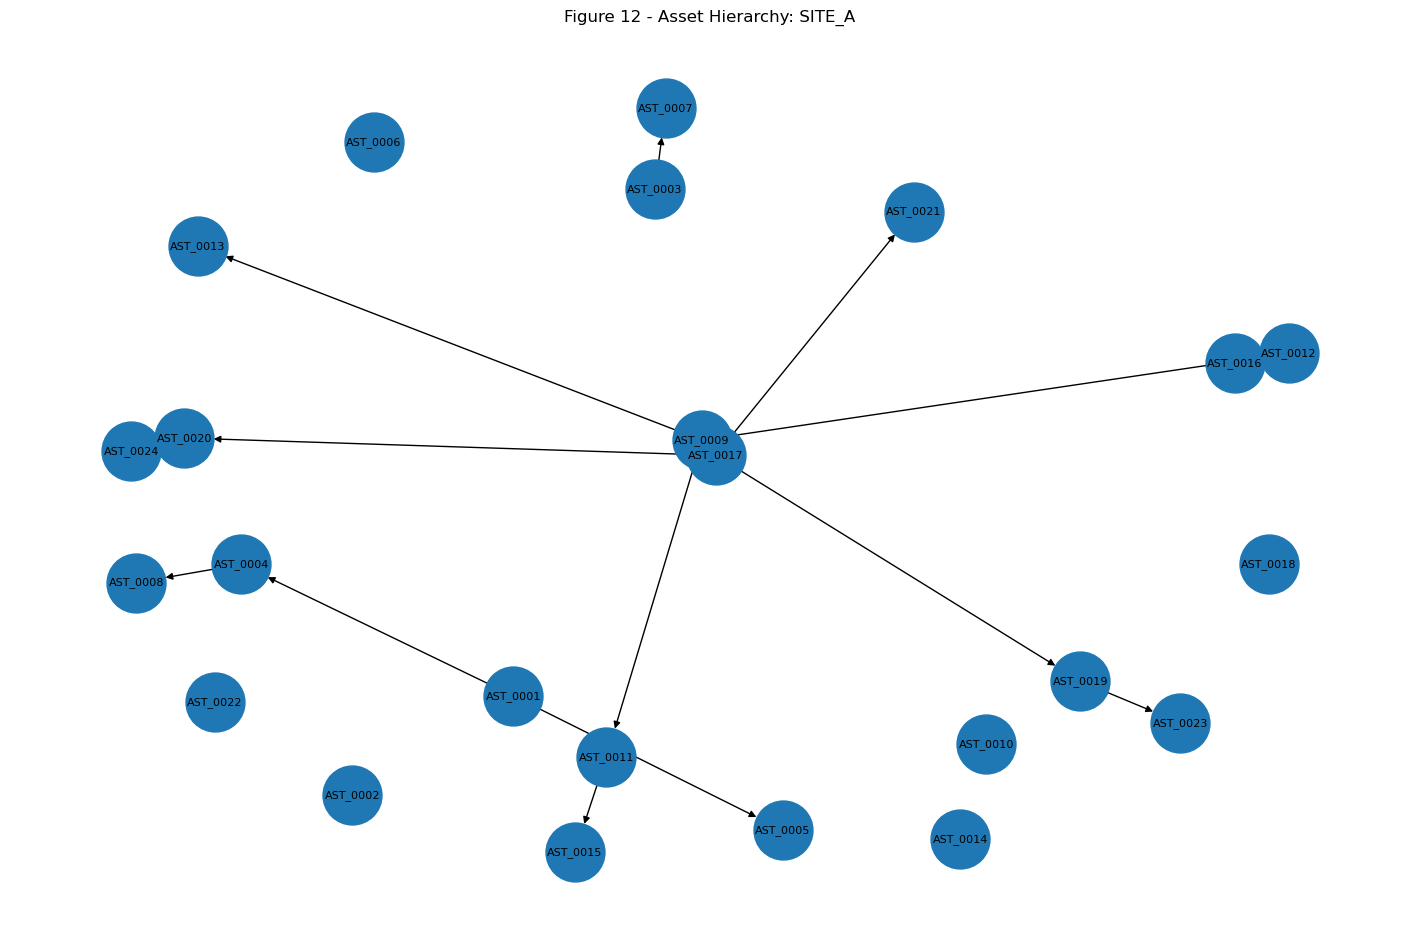

In [19]:
# ============================================================
# 11. ASSET HIERARCHY VISUALIZATION
# ============================================================

print("\n" + "=" * 70)
print("5. ASSET HIERARCHY VISUALIZATION")
print("=" * 70)


# Select first site

first_site = (
    assets["site_id"].iloc[0]
)

site_assets = assets[
    assets["site_id"]
    == first_site
]

site_ids = set(
    site_assets["asset_id"]
)

site_graph = hierarchy.subgraph(
    site_ids
).copy()


plt.figure(
    figsize=(14, 9)
)


pos = nx.spring_layout(
    site_graph,
    seed=42
)


nx.draw(
    site_graph,
    pos,
    with_labels=True,
    node_size=1800,
    font_size=8,
    arrows=True
)


plt.title(
    f"Figure 12 - Asset Hierarchy: {first_site}"
)

plt.tight_layout()

plt.savefig(
    FIGURES / "fig12_asset_hierarchy.png",
    dpi=130
)
plt.show()
plt.close()


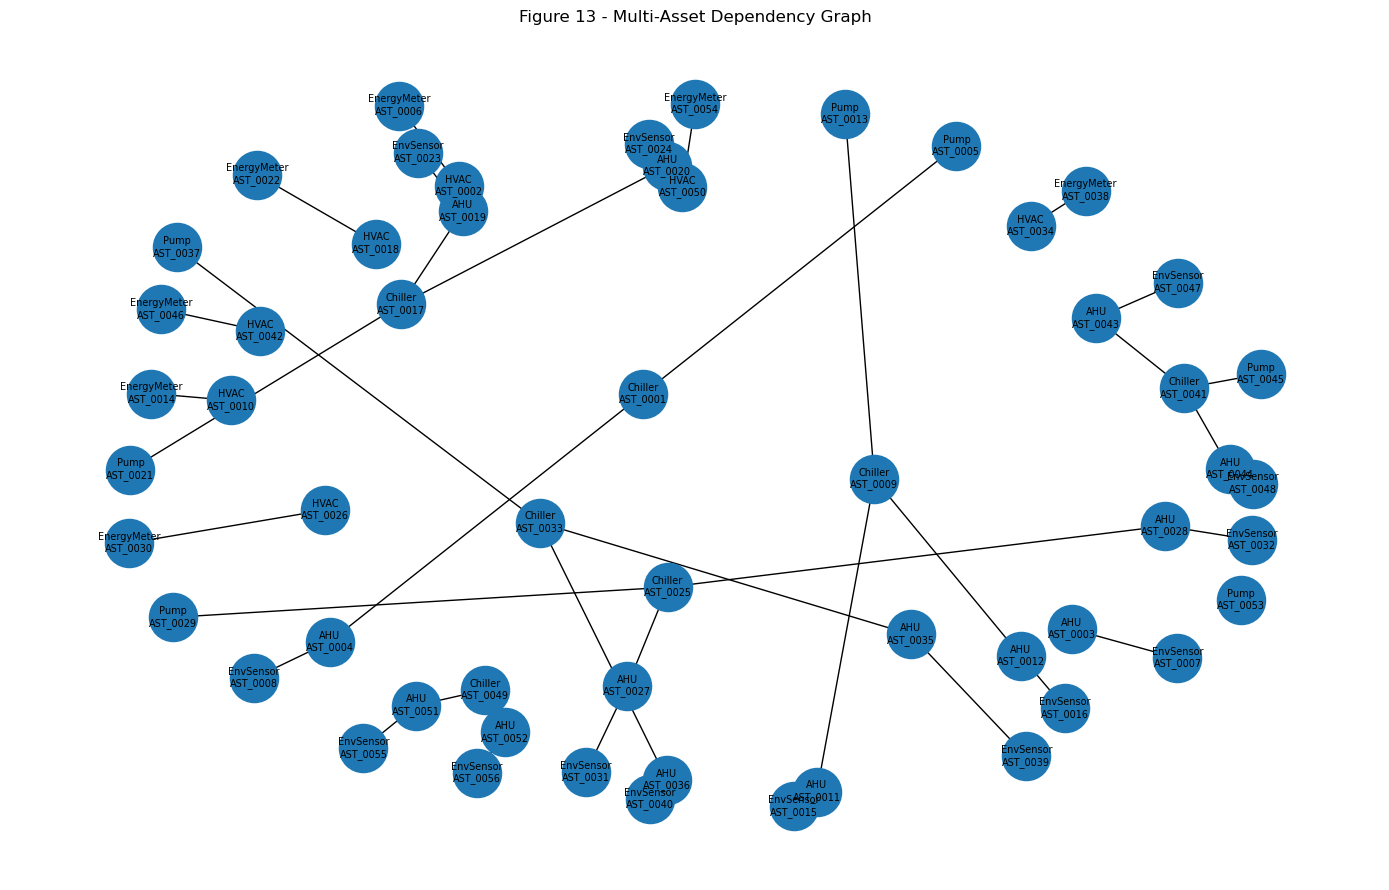

In [21]:

# ============================================================
# 12. DEPENDENCY GRAPH VISUALIZATION
# ============================================================

plt.figure(
    figsize=(14, 9)
)


pos = nx.spring_layout(
    G,
    seed=42
)


nx.draw_networkx_nodes(
    G,
    pos,
    node_size=1200
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowsize=15
)

labels = {
    node:
        G.nodes[node]["asset_type"]
        + "\n"
        + str(node)
    for node in G.nodes
}


nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=7
)


plt.title(
    "Figure 13 - Multi-Asset Dependency Graph"
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    FIGURES / "fig13_dependency_graph.png",
    dpi=130
)
plt.show()
plt.close()


In [24]:
# ============================================================
# 13. SAVE + DISPLAY COMPLETE REPORT
# ============================================================

summary = {

    "total_assets":
        int(G.number_of_nodes()),

    "total_relationships":
        int(G.number_of_edges()),

    "isolated_assets":
        isolated_assets,

    "missing_relationships":
        missing_relationships[
            "asset_id"
        ].tolist(),

    "duplicate_connections":
        duplicate_connections[
            [
                "source_asset_id",
                "target_asset_id",
                "connection_type"
            ]
        ].to_dict("records"),

    "orphan_assets":
        orphan_assets[
            "asset_id"
        ].tolist(),

    "invalid_parent_child_mappings":
        invalid_parent_mapping[
            [
                "asset_id",
                "parent_asset_id"
            ]
        ].to_dict("records"),

    "chiller_failure":
        chiller_failure,

    "pump_failure":
        pump_failure
}


# ------------------------------------------------------------
# Save JSON report
# ------------------------------------------------------------

report_path = (
    MODELS / "connectivity_analysis_report.json"
)

with open(report_path, "w") as file:

    json.dump(
        summary,
        file,
        indent=2,
        default=str
    )


# ============================================================
# DISPLAY REPORT IN JUPYTER NOTEBOOK
# ============================================================

from IPython.display import display, Markdown


display(
    Markdown(
        """
# Task 5 — Multi-Asset Connectivity Analysis

## Overall Graph Summary
"""
    )
)


summary_table = pd.DataFrame({
    "Metric": [
        "Total Assets",
        "Total Relationships",
        "Isolated Assets",
        "Missing Relationships",
        "Duplicate Connections",
        "Orphan Assets",
        "Invalid Parent-Child Mappings"
    ],

    "Count": [
        G.number_of_nodes(),
        G.number_of_edges(),
        len(isolated_assets),
        len(missing_relationships),
        len(duplicate_connections),
        len(orphan_assets),
        len(invalid_parent_mapping)
    ]
})


display(summary_table)


# ============================================================
# DATA QUALITY REPORT
# ============================================================

display(
    Markdown(
        """
## Data Quality Assessment
"""
    )
)


dq_table = pd.DataFrame({
    "Data Quality Check": [
        "Missing Relationships",
        "Duplicate Connections",
        "Orphan Assets",
        "Invalid Parent-Child Mappings"
    ],

    "Count": [
        len(missing_relationships),
        len(duplicate_connections),
        len(orphan_assets),
        len(invalid_parent_mapping)
    ]
})


display(dq_table)


# ============================================================
# ISOLATED ASSETS
# ============================================================

display(
    Markdown(
        """
## Isolated / Disconnected Assets
"""
    )
)


if isolated_assets:

    isolated_df = assets[
        assets["asset_id"].isin(
            isolated_assets
        )
    ][
        [
            "asset_id",
            "asset_name",
            "asset_type",
            "site_id",
            "building_id"
        ]
    ]

    display(isolated_df)

else:

    display(
        Markdown(
            "**No isolated assets found.**"
        )
    )


# ============================================================
# ASSET HIERARCHY
# ============================================================

display(
    Markdown(
        """
## Asset Hierarchy
"""
    )
)

display(
    hierarchy_df
)


# ============================================================
# CONNECTIVITY ANALYSIS
# ============================================================

display(
    Markdown(
        """
## Connectivity Analysis
"""
    )
)

display(
    connectivity_df.sort_values(
        "downstream_dependencies",
        ascending=False
    )
)


# ============================================================
# CRITICAL ASSETS
# ============================================================

display(
    Markdown(
        """
## Most Connected / Critical Assets
"""
    )
)

critical_assets = connectivity_df.sort_values(
    [
        "downstream_dependencies",
        "direct_connections"
    ],
    ascending=False
).head(10)

display(
    critical_assets
)


# ============================================================
# CHILLER FAILURE
# ============================================================

display(
    Markdown(
        """
## Chiller Failure Impact
"""
    )
)


if "impacted_assets" in chiller_failure:

    print(
        "Failed Asset:",
        chiller_failure["failed_asset"]
    )

    print(
        "Impacted Assets:",
        chiller_failure["impacted_asset_count"]
    )

    print(
        "Operational Impact:",
        chiller_failure["operational_impact"]
    )

    print(
        "Recommended Mitigation:",
        chiller_failure[
            "recommended_mitigation"
        ]
    )

    if chiller_failure["impacted_assets"]:

        impacted_chiller_df = assets[
            assets["asset_id"].isin(
                chiller_failure[
                    "impacted_assets"
                ]
            )
        ][
            [
                "asset_id",
                "asset_name",
                "asset_type",
                "site_id",
                "building_id"
            ]
        ]

        display(
            impacted_chiller_df
        )


# ============================================================
# PUMP FAILURE
# ============================================================

display(
    Markdown(
        """
## Pump Failure Impact
"""
    )
)


if "impacted_assets" in pump_failure:

    print(
        "Failed Asset:",
        pump_failure["failed_asset"]
    )

    print(
        "Impacted Assets:",
        pump_failure["impacted_asset_count"]
    )

    print(
        "Operational Impact:",
        pump_failure["operational_impact"]
    )

    print(
        "Recommended Mitigation:",
        pump_failure[
            "recommended_mitigation"
        ]
    )

    if pump_failure["impacted_assets"]:

        impacted_pump_df = assets[
            assets["asset_id"].isin(
                pump_failure[
                    "impacted_assets"
                ]
            )
        ][
            [
                "asset_id",
                "asset_name",
                "asset_type",
                "site_id",
                "building_id"
            ]
        ]

        display(
            impacted_pump_df
        )



print(
    f"\nFull JSON report saved to: {report_path}"
)


# Task 5 — Multi-Asset Connectivity Analysis

## Overall Graph Summary


,Metric,Count
0,Total Assets,56
1,Total Relationships,40
2,Isolated Assets,1
3,Missing Relationships,22
4,Duplicate Connections,2
5,Orphan Assets,1
6,Invalid Parent-Child Mappings,1



## Data Quality Assessment


,Data Quality Check,Count
0,Missing Relationships,22
1,Duplicate Connections,2
2,Orphan Assets,1
3,Invalid Parent-Child Mappings,1



## Isolated / Disconnected Assets


...


## Chiller Failure Impact


Failed Asset: AST_0001
Impacted Assets: 3
Operational Impact: Localized operational impact to dependent assets.
Recommended Mitigation: Isolate the failed asset, inspect downstream equipment, and switch to available backup systems.


,asset_id,asset_name,asset_type,site_id,building_id
3,AST_0004,AHU-0004,AHU,SITE_A,BLDG_001
4,AST_0005,Pump-0005,Pump,SITE_A,BLDG_001
7,AST_0008,EnvSensor-0008,EnvSensor,SITE_A,BLDG_001



## Pump Failure Impact


Failed Asset: AST_0005
Impacted Assets: 0
Operational Impact: Limited direct downstream impact.
Recommended Mitigation: Monitor the failed asset and perform maintenance or replacement.

Full JSON report saved to: d:\2026\Gowtham\Nector\Nectar_DataScientist_Challenge_Submission_FIXED\nectar_project\models\connectivity_analysis_report.json
